In [1]:
import os

In [2]:
from langgraph.graph import MessagesState, StateGraph, END, START 
from langchain_core.messages import HumanMessage, SystemMessage 
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import tools_condition # this is the checker for the if you got a tool back
from langgraph.prebuilt import ToolNode 
from IPython.display import display, Image 
from typing import Annotated, TypedDict 
import operator 
from langchain_core.messages import AnyMessage 
from langgraph.graph.message import add_messages 


d:\Code\Langchain\venv\Lib\site-packages\langgraph\graph\graph.py:30: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  from langgraph.pregel import Channel, Pregel


In [3]:
from langchain_openai import ChatOpenAI 
llm = ChatOpenAI()

In [4]:
def add(a : int, b : int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

In [5]:
def multiply(a : int, b : int ) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

In [6]:
def divide(a : int, b : int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b 

In [7]:
search = DuckDuckGoSearchRun()

In [9]:
tools = [add, multiply, divide, search]

In [10]:
llm_with_tools = llm.bind_tools(tools)

In [11]:
# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs.")

In [12]:
def reasoner(state: MessagesState):
    return {"messages" : [llm_with_tools.invoke([sys_msg] + state["messages"])]}

In [13]:
# Graph
builder = StateGraph(MessagesState)
#Add Nodes 
builder.add_node("reasoner", reasoner)
builder.add_node("tools", ToolNode(tools)) # For the tools 
# Add Edges 
builder.add_edge(START, "reasoner")
builder.add_conditional_edges(
    "reasoner", 
    tools_condition,
)
builder.add_edge("tools", "reasoner")
react_graph = builder.compile()

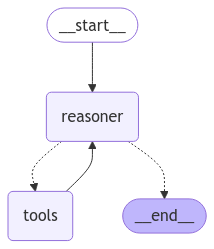

In [18]:
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [19]:
messages = [HumanMessage(content="What is 2 times of Donald Trump age?")]

In [20]:
messages = react_graph.invoke({"messages" : messages})

In [21]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 times of Donald Trump age?
================================== Ai Message ==================================
Tool Calls:
  multiply (call_aub6PHUk6bIO4NmfAyfxTcmL)
 Call ID: call_aub6PHUk6bIO4NmfAyfxTcmL
  Args:
    a: 2
    b: 75
================================= Tool Message =================================
Name: multiply

150
================================== Ai Message ==================================

2 times Donald Trump's age is 150.


In [22]:
messages = [HumanMessage(content="What is the result when you add 100 years to the current age of Elon Musk?")]

In [23]:
messages = react_graph.invoke({"messages": messages})

In [24]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the result when you add 100 years to the current age of Elon Musk?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_4KyTGdabdYBpeelTCGzcjFt4)
 Call ID: call_4KyTGdabdYBpeelTCGzcjFt4
  Args:
    query: current age of Elon Musk
================================= Tool Message =================================
Name: duckduckgo_search

Error: RatelimitException('https://links.duckduckgo.com/d.js?q=current+age+of+Elon+Musk&kl=wt-wt&l=wt-wt&p=&s=0&df=y&vqd=4-199046962779691686127967830602396878639&bing_market=wt-WT&ex=-1 202 Ratelimit')
 Please fix your mistakes.
================================== Ai Message ==================================

It seems there was an error with the search. Let me try a different approach to find the current age of Elon Musk.
Tool Calls:
  duckduckgo_search (call_1FUq5KUHiLupgpPVDZTS1ELL)
 Call ID: call_1F

In [26]:
import yfinance as yf 

def get_stock_price(ticker : str) -> float:
    """Gets a stock price from Yahoo Finance.

    Args:
        ticker: ticker str
    """
    # """This is a tool for getting the price of a stock when passed a ticker symbol"""
    stock = yf.Ticker(ticker)
    return stock.info["previousClose"]

In [27]:
get_stock_price("AAPL")

243.04

In [28]:
# Node
def reasoner(state):
    query = state["query"]
    messages = state["messages"]
    # System message
    sys_msg = SystemMessage(content="You are a helpful assistant tasked with using search, the yahoo finance tool and performing arithmetic on a set of inputs.")
    message = HumanMessage(content=query)
    messages.append(message)
    result = [llm_with_tools.invoke([sys_msg] + messages)]
    return {"messages":result}

In [29]:
tools = [add, multiply, divide, search, get_stock_price]

In [30]:
llm_with_tools = llm.bind_tools(tools)

In [31]:
class GraphState(TypedDict):
    """State of the graph."""
    query: str
    finance: str
    final_answer: str
    # intermediate_steps: Annotated[list[tuple[AgentAction, str]], operator.add]
    messages: Annotated[list[AnyMessage], operator.add]

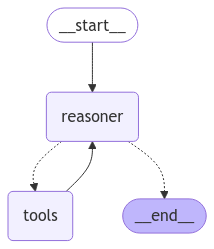

In [32]:
# Graph
workflow = StateGraph(GraphState)

# Add Nodes
workflow.add_node("reasoner", reasoner)
workflow.add_node("tools", ToolNode(tools)) # for the tools

# Add Edges
workflow.add_edge(START, "reasoner")

workflow.add_conditional_edges(
    "reasoner",
    # If the latest message (result) from node reasoner is a tool call -> tools_condition routes to tools
    # If the latest message (result) from node reasoner is a not a tool call -> tools_condition routes to END
    tools_condition,
)
workflow.add_edge("tools", "reasoner")
react_graph = workflow.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [34]:
response = react_graph.invoke({"query": "What is the stock price of Apple add 1000?", "messages": []})

In [35]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the stock price of Apple add 1000?
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (call_0G3RWXL98gfn0fmgtPVnBslk)
 Call ID: call_0G3RWXL98gfn0fmgtPVnBslk
  Args:
    ticker: AAPL
================================= Tool Message =================================
Name: get_stock_price

243.04
================================ Human Message =================================

What is the stock price of Apple add 1000?
================================== Ai Message ==================================
Tool Calls:
  add (call_gNfdVacbfQghHSO45zki9Qge)
 Call ID: call_gNfdVacbfQghHSO45zki9Qge
  Args:
    a: 24304
    b: 1000
================================= Tool Message =================================
Name: add

25304
================================ Human Message =================================

What is the stock price of Apple add 1000?
====